In [1]:
from pathlib import Path
import sys

root = Path.cwd()
if not (root / "src" / "phfno").is_dir():
    root = root.parent
assert (root / "src" / "phfno").is_dir(), "Run from the repository root or ipynb/."
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))

import torch
import neuralop
from phfno import PHFNO, FNOBaseline, RealFourierCoordinates

torch.manual_seed(7)
torch.set_num_threads(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python: {sys.executable}")
print(f"torch {torch.__version__}; neuraloperator {neuralop.__version__}")

Python: /home/scdlds_abhikrana/miniconda3/envs/research/bin/python
torch 2.11.0+cu128; neuraloperator 2.0.0


In [2]:
# Match Fourier cutoff, channels, and FNO size; PhFNO also learns energy and damping.
cutoff = (3,)
state_channels, control_channels = 2, 1
shared = dict(
    cutoff=cutoff,
    state_channels=state_channels,
    control_channels=control_channels,
    hidden_channels=8,
    n_layers=2,
)
ph = PHFNO(**shared, mlp_width=16, parameter_grid=(16,)).to(device)
baseline = FNOBaseline(**shared).to(device)
coordinates = RealFourierCoordinates(cutoff=cutoff, channels=state_channels).to(device)
models = {"PHFNO": ph, "FNO baseline": baseline}

for name, model in models.items():

    count = sum(p.numel() * (2 if p.is_complex() else 1) for p in model.parameters())
    print(f"{name}: {count:,} real parameters")

PHFNO: 2,823 real parameters
FNO baseline: 1,714 real parameters


In [3]:
batch_size, grid_size = 3, 16
# Fourier coordinates retain the selected modes with a grid-independent Parseval norm.
z = torch.randn(batch_size, coordinates.coordinate_dim, device=device, requires_grad=True)
v = coordinates.decode(z, (grid_size,))
torch.testing.assert_close(coordinates.encode(v), z, atol=2e-6, rtol=2e-6)
torch.testing.assert_close(
    v.square().sum(dim=1).mean(dim=-1), z.square().sum(dim=-1),
    atol=3e-6, rtol=3e-6,
)

# Autodiff supplies the energy gradient; skew exchange and squared damping define the dynamics.
energy = ph.energy(z)
effort = torch.autograd.grad(energy.sum(), z, create_graph=True)[0]
structure = ph.structure(z)
probe = torch.randn_like(effort)
control = torch.randn(batch_size, control_channels, device=device)
J_e = structure.apply_j(effort)
R_e = structure.apply_r(effort)
port_output = structure.output(effort)
rhs = J_e - R_e + structure.apply_b(control)

torch.testing.assert_close(
    (probe * J_e).sum(-1), -(effort * structure.apply_j(probe)).sum(-1),
    atol=2e-6, rtol=2e-5, 
)
# This is the continuous learned-energy balance, not a discrete AVF energy guarantee.
dissipation = (effort * R_e).sum(-1)
assert bool((dissipation >= -1e-7).all())
torch.testing.assert_close(
    (effort * rhs).sum(-1), -dissipation + (control * port_output).sum(-1),
    atol=2e-6, rtol=2e-5,
)
torch.testing.assert_close(ph.rhs_coordinates(z, control), rhs, atol=2e-6, rtol=2e-5)

# The fixed internal parameter grid gives the same coordinate dynamics on supported output grids.
fine_v = coordinates.decode(z.detach(), (32,))
fine_rhs = coordinates.encode(ph(fine_v, control))
coarse_rhs = coordinates.encode(ph(v.detach(), control))
torch.testing.assert_close(fine_rhs, coarse_rhs, atol=2e-5, rtol=2e-5)
print("Fourier, skew, dissipation, port balance, and evaluation-grid checks passed.")

Fourier, skew, dissipation, port balance, and evaluation-grid checks passed.


In [4]:
torch.manual_seed(11)
batch_size, grid_size = 4, 16
x = torch.arange(grid_size, device=device) / grid_size
phase = 2 * torch.pi * torch.rand(batch_size, 1, device=device)
amplitude = 0.5 + torch.rand(batch_size, 1, device=device)
q0 = amplitude * torch.sin(2 * torch.pi * x + phase)
p0 = 0.5 * amplitude * torch.cos(2 * torch.pi * x + phase)
times = torch.linspace(0, 0.12, 7, device=device)
t = times[None, :, None]
gamma, omega = 0.3, 1.2
decay, cosine, sine = torch.exp(-gamma * t), torch.cos(omega * t), torch.sin(omega * t)
q = decay * (q0[:, None, :] * cosine + p0[:, None, :] * sine)
p = decay * (p0[:, None, :] * cosine - q0[:, None, :] * sine)
trajectory = torch.stack((q, p), dim=2)
controls = torch.zeros(batch_size, len(times) - 1, control_channels, device=device)

v0, target, u0 = trajectory[:, 0], trajectory[:, 1], controls[:, 0]
dt = float(times[1] - times[0])
print("trajectory:", tuple(trajectory.shape), "controls:", tuple(controls.shape))

trajectory: (4, 7, 2, 16) controls: (4, 6, 1)


In [5]:
# This small interface demo intentionally uses Euler/MSE; the flow comparison uses AVF/H1.
# Differentiate through the state update and the energy gradient to train all model components.
optimizers = {name: torch.optim.Adam(model.parameters(), lr=1e-3)
              for name, model in models.items()}
loss_history = {name: [] for name in models}

for _ in range(3):
    for name, model in models.items():
        model.train()
        optimizers[name].zero_grad(set_to_none=True)
        prediction = model.step(v0, u0, dt, method="euler")
        loss = torch.nn.functional.mse_loss(prediction, target)
        assert bool(torch.isfinite(loss))
        loss.backward()
        gradients = [p.grad for p in model.parameters() if p.grad is not None]
        assert gradients and all(bool(torch.isfinite(g).all()) for g in gradients)
        optimizers[name].step()
        loss_history[name].append(float(loss.detach()))

for name, losses in loss_history.items():
    print(name, "one-step training MSE:", [f"{value:.3e}" for value in losses])

PHFNO one-step training MSE: ['2.016e-04', '2.015e-04', '2.015e-04']
FNO baseline one-step training MSE: ['2.047e-04', '2.040e-04', '2.033e-04']


PHFNO rollout: (4, 7, 2, 16)
FNO baseline rollout: (4, 7, 2, 16)


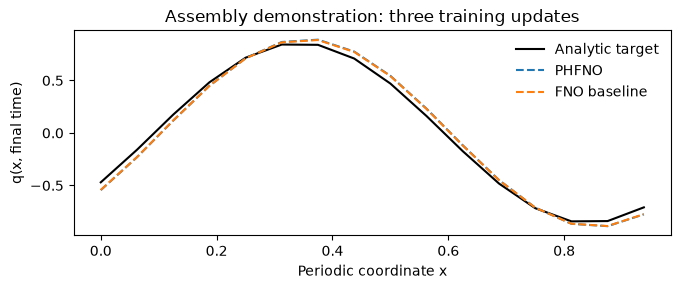

In [6]:
# Rollouts feed each prediction into the next step; the demonstration retains its Euler training method.
for model in models.values():
    model.eval()
with torch.no_grad():
    rollouts = {
        name: model.rollout(v0, controls, times, method="euler")
        for name, model in models.items()
    }
for name, predicted in rollouts.items():
    assert predicted.shape == trajectory.shape
    assert bool(torch.isfinite(predicted).all())
    print(name, "rollout:", tuple(predicted.shape))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x.cpu(), trajectory[0, -1, 0].cpu(), color="black", label="Analytic target")
for name, predicted in rollouts.items():
    ax.plot(x.cpu(), predicted[0, -1, 0].detach().cpu(), "--", label=name)
ax.set(xlabel="Periodic coordinate x", ylabel="q(x, final time)",
       title="Assembly demonstration: three training updates")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()